# Tokenization Study

## Datasets: Loading and Cleaning

### Itihasa

In [1]:
import requests

url = "https://raw.githubusercontent.com/rahular/itihasa/main/data/dev.sn"

data = requests.get(url).text.splitlines()

In [2]:
data[:2]

['तस्यां चीरं वसानायां नाथवत्यामनाथवत्। प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥',
 'तेन तत्र प्रणादेन दुःखितः स महीपतिः। चिच्छेद जीविते श्रद्धां धर्मे यशसि चात्मनः॥ स निःश्वस्योष्णमैक्ष्वाकस्तां भार्यामिदमब्रवीत्। कैकेयि कुशचीरेण न सीता गन्तुमर्हति॥']

In [3]:
# searching for Sandhis: This just means that this dataset has sandhis and is not a disolved dataset.

matches = [line for line in data if "ऽ" in line]

print(len(matches))
print(matches[0])

1096
रामेण यदि ते पापे किंचित्कृतमशोभनम्। अपकारः क इह ते वैदेह्या दर्शितोऽधमे॥


In [4]:
import re

def clean_text(corpus:list):

    texts = []

    for sentence in corpus:
      sentence = sentence.strip()

      # normalize whitespace
      sentence = re.sub(r"\s+", " ", sentence)
      sentence = re.sub(r"\.", "", sentence)

      # separate danda symbols
      sentence = re.sub(r"॥", " ॥ ", sentence)
      sentence = re.sub(r"।", " । ", sentence)

      # separate danda symbols
      # sentence = re.sub(r"\|\|", " || ", sentence)
      # sentence = re.sub(r"\|", " | ", sentence)

      # cleanup spaces again
      sentence = re.sub(r"\s+", " ", sentence)

      """
      The following are implemented after initial encoding <==> decoding
      comparision
      """

      # cleaning nukta consonants to base consonants
      char_map = {
          "क़": "क",
          "ख़": "ख",
          "ग़": "ग",
          "ज़": "ज",
          "फ़": "फ",
          "ऩ": "न",
          "ऱ": "र"}

      for old, new in char_map.items():
        sentence = sentence.replace(old, new)


      #  cleanup symbols
      sentence = re.sub(r"\s+", " ", sentence)



      texts.append(sentence)

    return texts

In [5]:
data = clean_text(data)
data[:2]

['तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥ ',
 'तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद जीविते श्रद्धां धर्मे यशसि चात्मनः ॥ स निःश्वस्योष्णमैक्ष्वाकस्तां भार्यामिदमब्रवीत् । कैकेयि कुशचीरेण न सीता गन्तुमर्हति ॥ ']

In [6]:
# Corpus Statistics:


def corpus_statistics(data):
  """
  corpus statistics
  """

# Calculate metrics for the dataset
  num_verses = len(data)

# Calculate num_lines by counting ' । ' and ' ॥ ' delimiters
  num_lines = 0
  for sentence in data:
    num_lines += sentence.count(' । ')
    num_lines += sentence.count(' ॥ ')


  total_characters = sum(len(sentence.replace(' ', '')) for sentence in data)
  total_words = sum(len(sentence.split()) for sentence in data)

  print(f"Number of verses: {num_verses}")
  print(f"Number of lines: {num_lines}")
  print(f"Total characters (excluding spaces): {total_characters}")
  print(f"Total words: {total_words}")

  # Calculate averages
  average_words_per_verse = total_words / num_verses
  average_chars_per_verse = total_characters / num_verses
  average_words_per_line = total_words / num_lines
  average_chars_per_line = total_characters / num_lines

  print(f"\n")
  print(f"Average words per verse: {average_words_per_verse:.2f}")
  print(f"Average characters per verse: {average_chars_per_verse:.2f}")
  print(f"Average words per line: {average_words_per_line:.2f}")
  print(f"Average characters per line: {average_chars_per_line:.2f}")

In [7]:
corpus_statistics(data)

Number of verses: 6148
Number of lines: 14487
Total characters (excluding spaces): 549817
Total words: 85680


Average words per verse: 13.94
Average characters per verse: 89.43
Average words per line: 5.91
Average characters per line: 37.95


## Loading the tokenizers

### GPT Tokenizers for old and new

In [8]:
# they live in the tiktoken environmemt, and here i can use the name as tokenizers using .encode:

import tiktoken
gpt_enc = tiktoken.get_encoding("cl100k_base")
o200k_enc = tiktoken.get_encoding("o200k_base")

### SentencePiece

As used by (Kumar, 2026)

In [9]:
import requests
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/sentencepiece/spm_sa.model

--2026-06-01 14:04:24--  https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/sentencepiece/spm_sa.model
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 448781 (438K) [application/octet-stream]
Saving to: ‘spm_sa.model’

spm_sa.model        100%[===================>] 438.26K  --.-KB/s    in 0.1s    

2026-06-01 14:04:25 (3.79 MB/s) - ‘spm_sa.model’ saved [448781/448781]



In [10]:
import sentencepiece as spm
from pathlib import Path

def load_spm(lang: str) -> spm.SentencePieceProcessor:
    sp = spm.SentencePieceProcessor()
    sp.load("spm_sa.model")
    return sp

In [11]:
sp_sa = load_spm("sa")

### SansGPT Tokenizer

In [30]:
!wget https://raw.githubusercontent.com/rhugvedd/SansGPT-Advancing-Generative-Pre-Training-in-Sanskrit/master/BPETokenizer.py
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/SansGPT/Final-Corpus-Tokenizer-Merge-Info-NL-12000-.pkl
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/SansGPT/Final-Corpus-Tokenizer-Vocab-NL-12000-.pkl

--2026-06-01 14:36:46--  https://raw.githubusercontent.com/rhugvedd/SansGPT-Advancing-Generative-Pre-Training-in-Sanskrit/master/BPETokenizer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22017 (22K) [text/plain]
Saving to: ‘BPETokenizer.py.1’

BPETokenizer.py.1   100%[===================>]  21.50K  --.-KB/s    in 0.005s  

2026-06-01 14:36:46 (4.31 MB/s) - ‘BPETokenizer.py.1’ saved [22017/22017]



In [33]:
vocab_path = "./"
merge_info_name = "Final-Corpus-Tokenizer-Merge-Info-NL-12000-"
vocab_name = "Final-Corpus-Tokenizer-Vocab-NL-12000-"

In [49]:
# SansGPT BPE Tokenizer:
# as implemented in paper

from BPETokenizer import BPETokenizer

Tokenizer = BPETokenizer()
Tokenizer.load(vocab_path, merge_info_name, vocab_name)

Loaded Vocabulary!
Vocab Size: 12000
MergeInfo Size: 11744


In [50]:
dir(Tokenizer)

['Decode',
 'DecodeVocab',
 'Encode',
 'EncodeFromText',
 'GetBigramStats',
 'GetCleanedText',
 'Merge',
 'MergeInfo',
 'PrintTokenizedText',
 'TrainVocab',
 'TrainVocab_fromText',
 'Vocab',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'count_bigrams',
 'load',
 'save',
 'special_tok',
 'special_tokens']

In [150]:
class SansGPTTokeinzer:
    """
    Thin adapter that makes BPETokenizer speak the same interface as every
    other tokenizer in the pipeline:

        .encode(sentence)   → flat list of int token IDs
        .tokenize(sentence) → list of token strings
        .decode(token_ids)  → decoded UTF-8 string

    The pipeline's tokenize() function calls these three methods.
    """

    def __init__(self, tok):
        self.tok = tok
        print(type(tok))

        # Metadata for benchmark tables

        self.vocab_size = len(tok.Vocab)
        self.name_or_path = tok.__class__.__name__

        self.backend_model = type(tok).__name__

        try:
          self.special_tokens_map = {
              "special_tokens": tok.special_tokens
              }
        except:
          self.special_tokens_map = {}





        # --- pre-build DecodedBytes lookup once, reuse across all calls ---
        # Rebuilding this per-call (as Decode() does internally) is O(vocab_size)
        # and would be expensive inside a sentence loop.


        self._decoded_bytes = {}
        for i in range(256):
            self._decoded_bytes[i] = bytes([i])
        for (m0, m1), mgd in self.tok.MergeInfo.items():
            self._decoded_bytes[mgd] = self._decoded_bytes[m0] + self._decoded_bytes[m1]

        print(f"[SansGPTTokenizerWrapper] Loaded. Vocab size: {len(self.tok.Vocab)}, "
              f"MergeInfo entries: {len(self.tok.MergeInfo)}")

    # ------------------------------------------------------------------
    # .encode(sentence) → flat list[int]
    # ------------------------------------------------------------------

    def encode(self, sentence: str) -> list:
        """
        EncodeFromText returns a LIST OF LISTS — one inner list per text
        segment produced by the similarity-word splitter in GetCleanedText.
        We flatten into a single list so the pipeline's tokenize() function
        gets a plain sequence of token IDs.
        """
        # WithoutNewLine=True  → joins lines with spaces (correct for inference)
        # SkipFirstChunkInLine=False → do not strip the first word of each line
        # Replacements={}      → no substitutions at inference time
        nested = self.tok.EncodeFromText(
            sentence,
            WithoutNewLine=False,
            SkipFirstChunkInLine=False,
            Replacements={}
        )
        # Flatten list-of-lists → flat list
        flat = [tok_id for segment in nested for tok_id in segment]
        return flat

    # ------------------------------------------------------------------
    # .tokenize(sentence) → list[str]
    # ------------------------------------------------------------------

    def tokenize(self, sentence: str) -> list:
        """
        Returns each token as a human-readable string.
        Uses the pre-built _decoded_bytes lookup so this is O(n_tokens).
        """
        token_ids = self.encode(sentence)
        token_strings = []
        for tid in token_ids:
            raw_bytes = self._decoded_bytes.get(tid, b'')
            token_strings.append(raw_bytes.decode('utf-8', errors='replace'))
        return token_strings

    # ------------------------------------------------------------------
    # .decode(token_ids) → str
    # ------------------------------------------------------------------

    def decode(self, token_ids: list, **kwargs) -> str:
        """
        Reconstructs a UTF-8 string from a flat list of token IDs.

        The pipeline's tokenize() function tries:
            tokenizer.decode(tokens, skip_special_tokens=True)
        and falls back to:
            tokenizer.decode(tokens)
        **kwargs absorbs skip_special_tokens so both call-sites work without error.
        """
        raw = b''.join(
            self._decoded_bytes.get(tid, b'')
            for tid in token_ids
        )
        return raw.decode('utf-8', errors='replace')

In [101]:
sansgpt = SansGPTTokeinzer(Tokenizer)

<class 'BPETokenizer.BPETokenizer'>
[SansGPTTokenizerWrapper] Loaded. Vocab size: 12000, MergeInfo entries: 11744


In [103]:
print(sansgpt.backend_model)

BPETokenizer


In [152]:
# Paste and run this cell immediately
print("Vocab size:      ", len(sansgpt.tok.Vocab))
print("MergeInfo size:  ", len(sansgpt.tok.MergeInfo))

# Check a few MergeInfo keys
sample = list(sansgpt.tok.MergeInfo.items())[:5]
print("Sample MergeInfo entries:")
for k, v in sample:
    print(f"  {k} → {v}  | key type: {type(k)}, element types: {type(k[0])}, {type(k[1])}")

Vocab size:       12000
MergeInfo size:   11744
Sample MergeInfo entries:
  (196, 129) → 256  | key type: <class 'tuple'>, element types: <class 'int'>, <class 'int'>
  (225, 185) → 257  | key type: <class 'tuple'>, element types: <class 'int'>, <class 'int'>
  (121, 97) → 258  | key type: <class 'tuple'>, element types: <class 'int'>, <class 'int'>
  (116, 97) → 259  | key type: <class 'tuple'>, element types: <class 'int'>, <class 'int'>
  (114, 97) → 260  | key type: <class 'tuple'>, element types: <class 'int'>, <class 'int'>


### Sutra

In [96]:
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer

login(userdata.get("HF_TOKEN"))

In [97]:
sutra = AutoTokenizer.from_pretrained("TWO/sutra-mlt256-v2")

### HF tokenizers

In [79]:
from transformers import AutoTokenizer

claude = AutoTokenizer.from_pretrained("Xenova/claude-tokenizer")
tiny = AutoTokenizer.from_pretrained("openaccess-ai-collective/tiny-mistral")
sutra = AutoTokenizer.from_pretrained("TWO/sutra-mlt256-v2")
qwen_sanskrit_model = AutoTokenizer.from_pretrained("diabolic6045/Sanskrit-Qwen2.5-7B-base")
qwen_sanskrit_tokenizer = AutoTokenizer.from_pretrained("diabolic6045/Sanskrit-English-qwen2-tokenizer")
mt5 = AutoTokenizer.from_pretrained("google/mt5-small")
mbart = AutoTokenizer.from_pretrained("facebook/mbart-large-50")
airavata = AutoTokenizer.from_pretrained("ai4bharat/Airavata") # needs login
llama = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct") # needs login # access granted
aya = AutoTokenizer.from_pretrained("CohereLabs/aya-expanse-8b") # needs login
gemma = AutoTokenizer.from_pretrained("google/gemma-1.1-2b-it") # needs login

tokenizer_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.77M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/626 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/963 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/34.2k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

## Metadata Tokenizers

In [107]:
import pandas as pd


def tokenizer_metadata_table(tokenizers_dict):

    rows = []

    for label, tok in tokenizers_dict.items():

        row = {
            "label": label,
            "class": getattr(tok, "backend_model", type(tok).__name__),
        }

        # -----------------------------
        # vocab size
        # -----------------------------

        if hasattr(tok, "vocab_size"):
          vocab = tok.vocab_size

          if callable(vocab):
            row["vocab_size"] = vocab()
          else:
            row["vocab_size"] = vocab

        elif hasattr(tok, "n_vocab"):

          row["vocab_size"] = tok.n_vocab

        else:

          row["vocab_size"] = "not available"

        # -----------------------------
        # model path / tokenizer name
        # -----------------------------
        if hasattr(tok, "name_or_path"):

            row["model_path"] = tok.name_or_path

        elif hasattr(tok, "name"):

            row["model_path"] = tok.name

        else:

            row["model_path"] = "not available"


        # -----------------------------
        # backend tokenizer model
        # -----------------------------
        try:

            row["backend_model"] = str(tok.backend_tokenizer.model)

        except:
          if hasattr(tok, "backend_model"):
            row["backend_model"] = tok.backend_model

          else:
            row["backend_model"] = tok.__class__.__name__


        # -----------------------------
        # special tokens
        # -----------------------------
        try:

            row["special_tokens"] = tok.special_tokens_map

        except:

            try:

                row["special_tokens"] = tok._special_tokens

            except:

                row["special_tokens"] = "not available"

        # -----------------------------
        # sentencepiece model
        # -----------------------------

        if type(tok).__name__ == "SentencePieceProcessor":
          row["model_path"] = getattr(tok, "_model_file", "SentencePiece Model")
          row["backend_model"] = type(tok).__name__

          try:
            row["special_tokens"] = {
                "unk_id": tok.unk_id(),
                "bos_id": tok.bos_id(),
                "eos_id": tok.eos_id(),
                "pad_id": tok.pad_id()
                }
          except:
            row["special_tokens"] = "not available"

        rows.append(row)

    df = pd.DataFrame(rows)

    return df

## Evaluation

In [109]:
tokenizers = {

    "claude": claude,
    "tiny_mistral": tiny,
    "sutra": sutra,
    "qwen_sanskrit_model": qwen_sanskrit_model,
    "qwen_sanskrit_tokenizer": qwen_sanskrit_tokenizer,
    "mt5": mt5,
    "mbart": mbart,
    "airavata" : airavata, # needs login
    "llama": llama, # needs login # access granted
    "aya": aya, # needs login
    "gemma": gemma, # needs login
    "cl100k_base": gpt_enc,
    "o200k_base": o200k_enc,
    "sentencepiece_sa": sp_sa,
    "sansgpt_tokenizer": sansgpt
}

meta_df = tokenizer_metadata_table(tokenizers)

meta_df

,label,class,vocab_size,model_path,backend_model,special_tokens
0,claude,GPT2Tokenizer,65000,Xenova/claude-tokenizer,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<EOT>', 'eos_token': '<EOT>', '..."
1,tiny_mistral,TokenizersBackend,32000,openaccess-ai-collective/tiny-mistral,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
2,sutra,TokenizersBackend,256001,TWO/sutra-mlt256-v2,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
3,qwen_sanskrit_model,Qwen2Tokenizer,151643,diabolic6045/Sanskrit-Qwen2.5-7B-base,"BPE(dropout=None, unk_token=None, continuing_s...","{'eos_token': '<|endoftext|>', 'pad_token': '<..."
4,qwen_sanskrit_tokenizer,TokenizersBackend,120000,diabolic6045/Sanskrit-English-qwen2-tokenizer,"BPE(dropout=None, unk_token=None, continuing_s...","{'eos_token': '<|im_end|>', 'unk_token': '<unk..."
5,mt5,T5Tokenizer,250100,google/mt5-small,"Unigram(unk_id=2, vocab=[(""<pad>"", 0), (""</s>""...","{'eos_token': '</s>', 'unk_token': '<unk>', 'p..."
6,mbart,MBart50Tokenizer,250054,facebook/mbart-large-50,"Unigram(unk_id=3, vocab=[(""<s>"", 0), (""<pad>"",...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
7,airavata,TokenizersBackend,48064,ai4bharat/Airavata,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
8,llama,TokenizersBackend,128000,meta-llama/Llama-3.1-8B-Instruct,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<|begin_of_text|>', 'eos_token'..."
9,aya,CohereTokenizer,255000,CohereLabs/aya-expanse-8b,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<BOS_TOKEN>', 'eos_token': '<|E..."


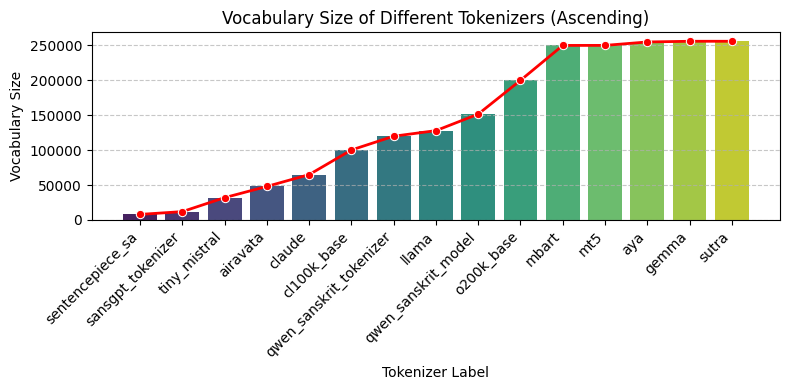

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort meta_df by vocab_size in ascending order
sorted_meta_df = meta_df.sort_values(by='vocab_size', ascending=True)

plt.figure(figsize=(8, 4))
sns.barplot(x='label', y='vocab_size', data=sorted_meta_df, palette='viridis', hue='label', legend=False, order=sorted_meta_df['label'])
# Add a rising red line
sns.lineplot(x='label', y='vocab_size', data=sorted_meta_df, color='red', marker='o', linewidth=2, sort=False)
plt.title('Vocabulary Size of Different Tokenizers (Ascending)')
plt.xlabel('Tokenizer Label')
plt.ylabel('Vocabulary Size')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [111]:
import pandas as pd
import numpy as np
from google.colab import files

def tokenize(data: list, tokenizer, tokenizer_label):
    """
    Tokenizes each sentence individually.
    Returns a DataFrame — one row per sentence.
    """

    records = []

    for sentence in data:

        if not sentence.strip():
            continue

        tokens = tokenizer.encode(sentence)

        try:
          token_strings = tokenizer.tokenize(sentence)
        except:
          token_strings = [tokenizer.decode([t]) for t in tokens] # Converts each token ID back into readable token text/subword like 15266 --> Hello

        words = sentence.split()

        num_tokens = len(tokens) # Number of total generated tokens per sentence
        num_words = len(words) # number of total words in sentence
        num_chars = len(sentence.replace(" ", "")) # total number of charachters --> in english one letter - one charachter

        try:
            decoded = tokenizer.decode(tokens, skip_special_tokens=True)
        except:
            decoded = tokenizer.decode(tokens)

        records.append({

            "sentence": sentence,
            "decoded_sentence": decoded,
            "tokens": token_strings,
            "similarity": sentence.strip() == decoded.strip(),
            "num_words": num_words,
            "num_tokens": num_tokens,
            # "unique_tokens_count": len(set(tokens)), # more useful at corpus level
            "token_ids": tokens,
            "num_chars": num_chars,
            "fertility": num_tokens / num_words if num_words > 0 else None, # Average tokens per word
            "tokens_per_char": num_tokens / num_chars if num_chars > 0 else None, # how many tokens needed to represent one charachter
            "chars_per_token": num_chars / num_tokens if num_tokens > 0 else None, # aka Compression Ratio , how many chars packed into one token?
            "tokenizer": tokenizer_label
        })

    df = pd.DataFrame(records)

    #filename = f"tokenizer_analysis_{tokenizer_label}.xlsx"

    #df.to_excel(filename, index=False)

    #files.download(filename)

    return df

In [135]:
test = data[0]
print(test)
ids = sansgpt.encode(test)

print(ids)

#print(Tokenizer.Decode(ids[:10]))
print(Tokenizer.Decode(ids))

import inspect

print(inspect.getsource(BPETokenizer.Decode))
help(Tokenizer.Decode)

तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥ 
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
[224, 164, 164, 224, 164, 184, 268, 141, 224, 164, 175, 224, 164, 190, 224, 164, 130, 32, 224, 164, 154, 268, 128, 224, 164, 176, 224, 164, 130, 32, 224, 164, 181, 224, 164, 184, 224, 164, 190, 224, 164, 168, 224, 164, 190, 224, 164, 175, 224, 164, 190, 224, 164, 130, 32, 224, 164, 168, 224, 164, 190, 224, 164, 165, 224, 164, 181, 224, 164, 164, 268, 141, 224, 164, 175, 224, 164, 190, 224, 164, 174, 224, 164, 168, 224, 164, 190, 224, 164, 165, 224, 164, 181, 224, 164, 164, 268, 141, 277, 32, 224, 164, 170, 268, 141, 224, 164, 176, 224, 164, 154, 268, 129, 224, 164, 149, 268, 141, 224, 164, 176, 268, 139, 224, 164, 182, 32, 224, 164, 156, 224, 164, 168, 224, 164, 131, 32, 224, 164, 184, 224, 164, 176, 268, 141, 224, 164, 181, 268, 139, 32, 224, 164, 167, 224, 164, 191, 224, 164, 149, 268, 141, 32, 224, 164, 164, 268, 141, 224, 164, 181, 

In [140]:
test = data[0]
print(test)
ids = sansgpt.encode(test)

print(ids)
print(type(tokens))
print(tokens)
len(tokens)

Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
<class 'list'>
[[224, 164, 164, 224, 164, 184], [268, 141, 224, 164, 175], [224, 164, 190, 224, 164, 130], [32, 224, 164, 154], [268, 128, 224, 164, 176], [224, 164, 130], [32, 224, 164, 181, 224, 164, 184], [224, 164, 190, 224, 164, 168], [224, 164, 190, 224, 164, 175], [224, 164, 190, 224, 164, 130], [32, 224, 164, 168], [224, 164, 190, 224, 164, 165, 224, 164, 181, 224, 164, 164], [268, 141, 224, 164, 175], [224, 164, 190, 224, 164, 174, 224, 164, 168], [224, 164, 190, 224, 164, 165, 224, 164, 181, 224, 164, 164], [268, 141], [277], [32, 224, 164, 170], [268, 141, 224, 164, 176, 224, 164, 154], [268, 129, 224, 164, 149], [268, 141, 224, 164, 176], [268, 139, 224, 164, 182], [32, 224, 164, 156, 224, 164, 168], [224, 164, 131], [32, 224, 164, 184, 224, 164, 176], [268, 141, 224, 164, 181], [268, 139], [32, 224, 164, 167], [224, 164, 191, 224, 164, 149], [268, 141], [32, 224, 164, 164], [268, 141, 224, 164, 181], [224, 16

41

In [148]:
test = data[0]
print(test)

tokens = sansgpt.encode(test)
print("\n")
print(tokens)
print(type(tokens))
print(tokens)
print(len(tokens))


Tokens = Tokenizer.EncodeFromText(
    test,
    WithoutNewLine=False,
    SkipFirstChunkInLine=False,
    Replacements={}
)

print("\n")
print(Tokens)
print(type(Tokens))
print(Tokens)
print(len(Tokens))

तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥ 
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)


[224, 164, 164, 224, 164, 184, 268, 141, 224, 164, 175, 224, 164, 190, 224, 164, 130, 32, 224, 164, 154, 268, 128, 224, 164, 176, 224, 164, 130, 32, 224, 164, 181, 224, 164, 184, 224, 164, 190, 224, 164, 168, 224, 164, 190, 224, 164, 175, 224, 164, 190, 224, 164, 130, 32, 224, 164, 168, 224, 164, 190, 224, 164, 165, 224, 164, 181, 224, 164, 164, 268, 141, 224, 164, 175, 224, 164, 190, 224, 164, 174, 224, 164, 168, 224, 164, 190, 224, 164, 165, 224, 164, 181, 224, 164, 164, 268, 141, 277, 32, 224, 164, 170, 268, 141, 224, 164, 176, 224, 164, 154, 268, 129, 224, 164, 149, 268, 141, 224, 164, 176, 268, 139, 224, 164, 182, 32, 224, 164, 156, 224, 164, 168, 224, 164, 131, 32, 224, 164, 184, 224, 164, 176, 268, 141, 224, 164, 181, 268, 139, 32, 224, 164, 167, 224, 164, 191, 224, 164, 149, 268, 141, 32, 224, 164, 164, 268, 141, 224, 164, 181

In [149]:
for chunk in Tokens[:10]:
    print(chunk)
    print(Tokenizer.Decode(chunk))
    print("------")

[224, 164, 164, 224, 164, 184]
तस
------
[268, 141, 224, 164, 175]
्य
------
[224, 164, 190, 224, 164, 130]
ां
------
[32, 224, 164, 154]
 च
------
[268, 128, 224, 164, 176]
ीर
------
[224, 164, 130]
ं
------
[32, 224, 164, 181, 224, 164, 184]
 वस
------
[224, 164, 190, 224, 164, 168]
ान
------
[224, 164, 190, 224, 164, 175]
ाय
------
[224, 164, 190, 224, 164, 130]
ां
------


## Tokenizer wise results:

In [112]:
tokenize(data, qwen_sanskrit_tokenizer,"qwen_sanskrit_tokenizer").head(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁तस्यां, ▁ची, रं, ▁वस, ान, ायां, ▁नाथ, वत्या,...",True,13,21,"[6347, 23964, 645, 2778, 245, 1616, 6661, 1747...",73,1.615385,0.287671,3.476190,qwen_sanskrit_tokenizer
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[▁तेन, ▁तत्र, ▁प्रण, ादेन, ▁दुःखितः, ▁स, ▁महीप...",True,24,36,"[1414, 769, 2187, 74435, 21910, 223, 10427, 22...",146,1.500000,0.246575,4.055556,qwen_sanskrit_tokenizer


In [ ]:
tokenize(data, claude,"claude").head(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤, ¯, à¤¾, à¤Ĥ, Ġà¤, ļ, à¥Ģ, ...",True,13,103,"[45793, 56377, 38639, 5333, 112, 24332, 40786,...",73,7.923077,1.410959,0.708738,claude
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[à¤¤, à¥ĩ, à¤¨, Ġà¤, ¤, à¤¤, à¥į, à¤°, Ġà¤, ª,...",True,24,203,"[45793, 29050, 37134, 13348, 102, 45793, 38639...",146,8.458333,1.390411,0.719212,claude


In [ ]:
tokenize(data, gpt_enc,"cl100k_base").head(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[त, स, ्�, �, ा�, �, �, �, ी, र, ं, �, �, स,...",True,13,91,"[80338, 79468, 31584, 107, 32511, 224, 15272, ...",73,7.000000,1.246575,0.802198,cl100k_base
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[त, े�, �, �, �, त, ्र, प, ्र, �, �, ा�, �, ...",True,24,179,"[80338, 55884, 101, 15272, 97, 80338, 86133, 8...",146,7.458333,1.226027,0.815642,cl100k_base


In [117]:
tokenizer_names = []

tokenizers = [

    ("claude", claude),
    ("tiny", tiny),
    ("sutra", sutra),
    ("qwen_sanskrit_model", qwen_sanskrit_model),
    ("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer),
    ("mt5", mt5),
    #("mbart", mbart),
    ("airavata" , airavata), # needs login
    ("llama", llama), # needs login # access granted
    ("aya", aya), # needs login
    ("gemma", gemma), # needs login
    ("cl100k_base", gpt_enc),
    ("o200k_base", o200k_enc),
    ("sentencepiece_sa", sp_sa),
    ("sansgpt_tokenizer", sansgpt)

]

for tok, name in tokenizers:
  #print(f"Running {name}")
  temp_df = tokenize(data, name, tok)
  tokenizer_names.append(temp_df)

df = pd.concat(tokenizer_names, ignore_index = True)

Streaming output truncated to the last 5000 lines.
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding from Vocab - (Size: 12000)
Cleaning and splitting text.
Encoding f

In [118]:
# uncomment to download a file

"""

filename = f"tokenizer_analysis.xlsx"

df.to_excel(filename, index=False)

files.download(filename)

"""

'\n\nfilename = f"tokenizer_analysis.xlsx"\n\ndf.to_excel(filename, index=False)\n\nfiles.download(filename)\n\n'

In [119]:
df['tokenizer'].unique()

array(['claude', 'tiny', 'sutra', 'qwen_sanskrit_model',
       'qwen_sanskrit_tokenizer', 'mt5', 'airavata', 'llama', 'aya',
       'gemma', 'cl100k_base', 'o200k_base', 'sentencepiece_sa',
       'sansgpt_tokenizer'], dtype=object)

In [120]:
df.head(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤, ¯, à¤¾, à¤Ĥ, Ġà¤, ļ, à¥Ģ, ...",True,13,103,"[45793, 56377, 38639, 5333, 112, 24332, 40786,...",73,7.923077,1.410959,0.708738,claude
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[à¤¤, à¥ĩ, à¤¨, Ġà¤, ¤, à¤¤, à¥į, à¤°, Ġà¤, ª,...",True,24,203,"[45793, 29050, 37134, 13348, 102, 45793, 38639...",146,8.458333,1.390411,0.719212,claude


In [121]:
df.tail(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
86070,योनिस्त्वमस्य प्रलयश्च कृष्ण त्वमेवेदं सृजसे व...,योनिस्त्वमस्य प्रलयश्च कृष्ण त्वमेवेदं सृजसे व...,"[�, �, �, �, �, �, �, �, �, �, �, �, �, �, �, ...",True,15,290,"[224, 164, 175, 268, 139, 224, 164, 168, 224, ...",103,19.333333,2.815534,0.355172,sansgpt_tokenizer
86071,एवं स्तुतो धर्मराजेन कृष्णः सभामध्ये प्रीतिमान...,एवं स्तुतो धर्मराजेन कृष्णः सभामध्ये प्रीतिमान...,"[�, �, �, �, �, �, �, �, �, , �, �, �, �, �, ...",True,15,325,"[224, 164, 143, 224, 164, 181, 224, 164, 130, ...",114,21.666667,2.850877,0.350769,sansgpt_tokenizer


In [122]:
df[df['sentence'] == "तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥ "]

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤, ¯, à¤¾, à¤Ĥ, Ġà¤, ļ, à¥Ģ, ...",True,13,103,"[45793, 56377, 38639, 5333, 112, 24332, 40786,...",73,7.923077,1.410959,0.708738,claude
6148,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁, त, स, ्, य, ा, ं, ▁, च, ी, र, ं, ▁, व, स, ...",True,13,92,"[1, 28705, 29708, 29671, 29300, 29896, 29232, ...",73,7.076923,1.260274,0.793478,tiny
12296,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁त, स, ्यां, ▁ची, र, ं, ▁वसा, ना, य, ां, ▁ना,...",False,13,44,"[256012, 7982, 772, 36483, 28974, 765, 724, 16...",73,3.384615,0.602740,1.659091,sutra
18444,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥įà¤, ¯, à¤¾à¤, Ĥ, Ġà¤, ļ, à¥Ģ, à¤...",True,13,83,"[79238, 78368, 30484, 107, 31411, 224, 14925, ...",73,6.384615,1.136986,0.879518,qwen_sanskrit_model
24592,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁तस्यां, ▁ची, रं, ▁वस, ान, ायां, ▁नाथ, वत्या,...",True,13,21,"[6347, 23964, 645, 2778, 245, 1616, 6661, 1747...",73,1.615385,0.287671,3.476190,qwen_sanskrit_tokenizer
30740,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁, तस्, यां, ▁, ची, रं, ▁, वसा, ना, यां, ▁, न...",True,13,45,"[259, 92038, 108720, 259, 8040, 111093, 259, 1...",73,3.461538,0.616438,1.622222,mt5
36888,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁, त, स्, यां, ▁, ची, र, ं, ▁व, सा, ना, यां, ...",True,13,51,"[1, 29871, 30475, 32513, 34124, 29871, 33447, ...",73,3.923077,0.698630,1.431373,airavata
43036,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥įà¤¯, à¤¾à¤Ĥ, Ġà¤ļ, à¥Ģà¤°, à¤Ĥ, ...",True,13,49,"[128000, 80338, 79468, 100305, 100515, 100443,...",73,3.769231,0.671233,1.489796,llama
49184,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤¯, à¤¾à¤Ĥ, Ġà¤ļ, à¥Ģ, à¤°, à...",True,13,64,"[5, 2560, 2960, 2173, 2857, 10451, 10116, 2491...",73,4.923077,0.876712,1.140625,aya
55332,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[त, स्या, ं, ▁ची, र, ं, ▁व, सा, ना, या, ं, ▁ना...",True,13,46,"[2, 235550, 137542, 235563, 112889, 235462, 23...",73,3.538462,0.630137,1.586957,gemma


### Encoding and Decoding Similarity:

In [ ]:
df['similarity'].value_counts()

,count
similarity,
True,61662
False,24410


In [ ]:
df[df['similarity'] == False][['similarity','tokenizer']].drop_duplicates()

,similarity,tokenizer
1475,False,claude
12296,False,sutra
24617,False,qwen_sanskrit_tokenizer
30740,False,mt5
36888,False,mbart
50659,False,llama
79924,False,sentencepiece_sa


## Summary of Metrices

In [123]:
summary = (
    df
    .groupby("tokenizer")
    .agg({
        "num_words": "mean",
        "num_tokens": "mean",
        "fertility": "mean",
        "tokens_per_char": "mean",
        "chars_per_token": "mean"
    })
    .sort_values("fertility", ascending=True)
)
summary_round = round(summary, 1)
summary_round

,num_words,num_tokens,fertility,tokens_per_char,chars_per_token
tokenizer,,,,,
qwen_sanskrit_tokenizer,13.9,21.8,1.6,0.2,4.1
sentencepiece_sa,13.9,37.9,2.8,0.4,2.4
mt5,13.9,48.5,3.6,0.5,1.8
o200k_base,13.9,49.6,3.7,0.6,1.8
sutra,13.9,50.3,3.7,0.6,1.8
gemma,13.9,53.6,3.9,0.6,1.7
airavata,13.9,60.7,4.5,0.7,1.5
llama,13.9,62.1,4.6,0.7,1.4
aya,13.9,82.7,6.1,0.9,1.1


/tmp/ipykernel_1474/3856549932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


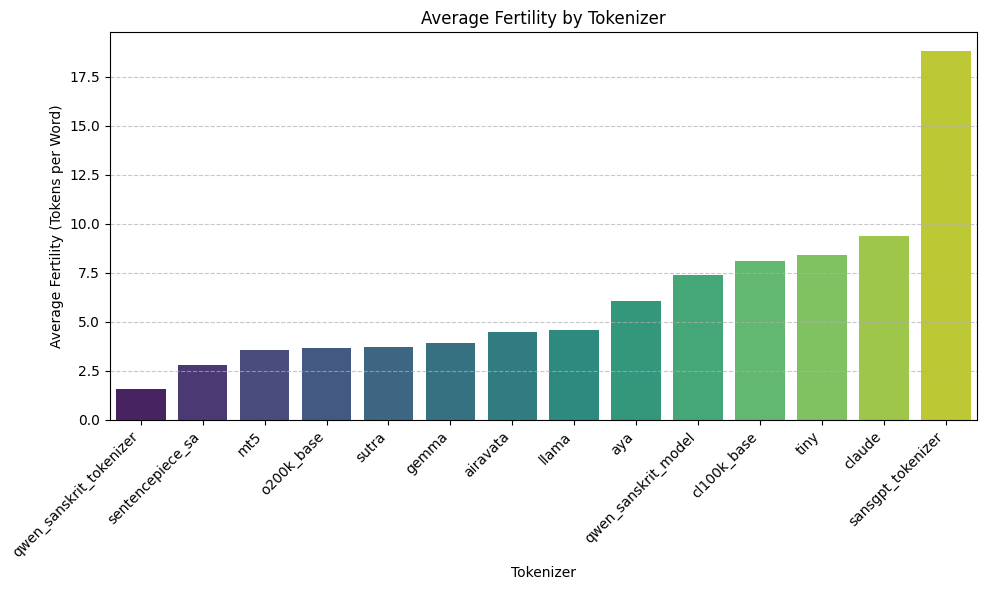

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fertility per tokenizer
fertility_summary = (
    df.groupby('tokenizer')['fertility']
      .mean()
      .reset_index()
      .sort_values('fertility', ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='tokenizer',
    y='fertility',
    data=fertility_summary,
    palette='viridis'
)

plt.title('Average Fertility by Tokenizer')
plt.xlabel('Tokenizer')
plt.ylabel('Average Fertility (Tokens per Word)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion

# Vedic Corpus

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
vedic = load_dataset("shunyasea/vedic-sanskrit")

README.md:   0%|          | 0.00/547 [00:00<?, ?B/s]

data/train-00000-of-00002-61fefd9cb3342d(…):   0%|          | 0.00/14.4M [00:00<?, ?B/s]

data/train-00001-of-00002-2c3d06867eb941(…):   0%|          | 0.00/14.4M [00:00<?, ?B/s]

data/test-00000-of-00001-89162c07a955ac3(…):   0%|          | 0.00/3.21M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/536641 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/59627 [00:00<?, ? examples/s]

In [ ]:
print(vedic)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 536641
    })
    test: Dataset({
        features: ['text'],
        num_rows: 59627
    })
})


In [ ]:
vedic = vedic["test"]["text"]

In [ ]:
vedic[:5]

['वित्रेसुः सर्वभूतानि कषयं पराप्तं च मेनिरे',
 'परिष्ठिता अत्र्णद बद्बधानाः सीरा इन्द्रः सरवितवे पर्थिव्या|',
 'सयावानं धनेधने वाजयन्तम अवा रथम|',
 'त्वं च सङ्कर्षणो देवस्त्वं कर्ता त्वं सनातनः ।',
 'जितेन्द्रियश च वसुधां पराप्स्यसीति च माब्रवीत']

In [ ]:
len(vedic)

59627

In [ ]:
vedic = clean_text(vedic)

In [ ]:
corpus_statistics(vedic)

Number of verses: 59627
Number of lines: 15549
Total characters (excluding spaces): 2085043
Total words: 345430


Average words per verse: 5.79
Average characters per verse: 34.97
Average words per line: 22.22
Average characters per line: 134.09


In [ ]:
tokenizer_names = []

tokenizers = [

    ("claude", claude),
    ("tiny", tiny),
    ("sutra", sutra),
    ("qwen_sanskrit_model", qwen_sanskrit_model),
    ("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer),
    ("mt5", mt5),
    ("mbart", mbart),
    ("airavata" , airavata), # needs login
    ("llama", llama), # needs login # access granted
    ("aya", aya), # needs login
    ("gemma", gemma), # needs login
    ("cl100k_base", gpt_enc),
    ("o200k_base", o200k_enc),


]

for tok, name in tokenizers:
  temp_df = tokenize(vedic, name, tok)
  tokenizer_names.append(temp_df)

df = pd.concat(tokenizer_names, ignore_index = True)

In [ ]:
summary = (
    df
    .groupby("tokenizer")
    .agg({
        "num_words": "mean",
        "num_tokens": "mean",
        "fertility": "mean",
        "tokens_per_char": "mean",
        "chars_per_token": "mean"
    })
    .sort_values("fertility", ascending=True)
)
summary_round = round(summary, 1)
summary_round

,num_words,num_tokens,fertility,tokens_per_char,chars_per_token
tokenizer,,,,,
qwen_sanskrit_tokenizer,6.0,10.7,1.9,0.3,3.6
mbart,6.0,19.0,3.5,0.6,1.9
mt5,6.0,20.5,3.7,0.6,1.8
o200k_base,6.0,21.1,3.8,0.6,1.7
sutra,6.0,21.9,4.0,0.6,1.6
gemma,6.0,23.1,4.2,0.7,1.6
airavata,6.0,25.5,4.6,0.7,1.4
llama,6.0,25.9,4.7,0.7,1.4
aya,6.0,33.3,6.1,0.9,1.1


/tmp/ipykernel_2585/3856549932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


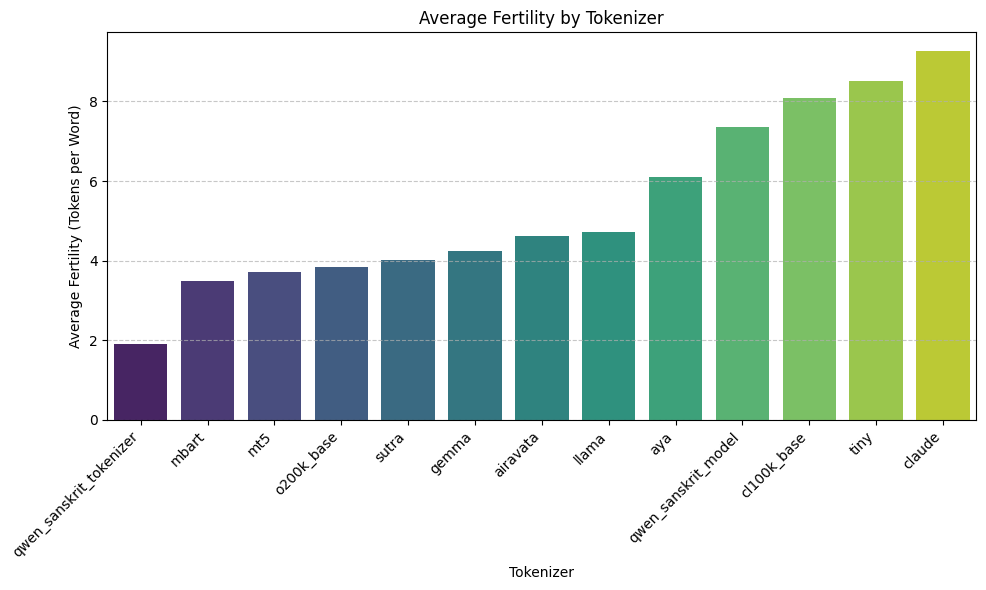

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fertility per tokenizer
fertility_summary = (
    df.groupby('tokenizer')['fertility']
      .mean()
      .reset_index()
      .sort_values('fertility', ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='tokenizer',
    y='fertility',
    data=fertility_summary,
    palette='viridis'
)

plt.title('Average Fertility by Tokenizer')
plt.xlabel('Tokenizer')
plt.ylabel('Average Fertility (Tokens per Word)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()